# 02 — Cleaning and deriving `opportunity`

**Input:** `data/processed/raw_subset.parquet` (6,123,270 rows)
**Output:** `data/processed/interactions_clean.parquet` and `data/processed/provenance.csv`

Steps:

1. Remove rows that can't be used, and record how many and why.
2. Derive `opportunity` (practice count per student and skill) from timestamps, since this release doesn't include it.
3. Select five skills.
4. Check that accuracy rises with practice before fitting BKT.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

EATS = Path(r"C:\Users\vedac\Desktop\EATS")
sys.path.insert(0, str(EATS))

PROCESSED = EATS / "data" / "processed"
FIGURES = EATS / "results" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 9

df = pd.read_parquet(PROCESSED / "raw_subset.parquet")
print(f"loaded {len(df):,} rows")
df.head(3)

loaded 6,123,270 rows


,skill,problem_id,user_id,assignment_id,start_time,original,correct,bottom_hint,hint_count,attempt_count,ms_first_response,skill_id
0,NaN,557460.0,61394.0,565736.0,2012-09-28 15:11:27,1.0,1.0,0.0,0.0,1.0,9852.0,NaN
1,Rounding,365981.0,61394.0,573819.0,2012-10-09 11:01:52,1.0,1.0,0.0,0.0,1.0,21175.0,54.0
2,Multiplication and Division Integers,426415.0,61394.0,734130.0,2013-03-07 10:53:20,1.0,0.0,0.0,0.0,1.0,8645.0,279.0


## 2.1 Provenance log

Each filter records how many rows it removed and why, so the row counts can be traced from the raw file to the final dataset.

In [2]:
class Provenance:
    """Records the row count after each cleaning step, with a justification."""

    def __init__(self, n_start, label="Raw subset, notebook 01"):
        self.rows = [(label, n_start, 0, "12 of 35 columns")]

    def record(self, label, n_now, why):
        removed = self.rows[-1][1] - n_now
        self.rows.append((label, n_now, removed, why))

    def frame(self):
        return pd.DataFrame(
            self.rows, columns=["step", "rows_remaining", "rows_removed", "justification"]
        )


prov = Provenance(len(df))
print("provenance log started")

provenance log started


## 2.2 Cleaning

The filters below run in order.

In [3]:
# --- 1. `correct` must be binary --------------------------------------------
# Check before trusting it - if this column holds anything other than 0/1 the
# accuracy figure and the whole BKT likelihood are meaningless.
print("distinct `correct` values:", sorted(df["correct"].dropna().unique())[:10])

df = df[df["correct"].isin([0.0, 1.0])]
prov.record("Binary `correct` only", len(df), "0/1 required for BKT likelihood")

# --- 2. Skill tag required ---------------------------------------------------
# BKT is fitted per skill. An untagged interaction belongs to no knowledge
# component, so it cannot inform any student model.
df = df[df["skill"].notna()]
prov.record("Skill-tagged", len(df), "BKT is fitted per knowledge component")

# --- 3. Main problems only ---------------------------------------------------
# original == 0 marks scaffolding sub-questions, shown only AFTER a student has
# already answered the parent problem wrongly. Counting both double-counts one
# attempt and biases accuracy downwards.
df = df[df["original"] == 1]
prov.record("Main problems only", len(df), "Scaffolding duplicates the parent attempt")

# --- 4. Valid response times -------------------------------------------------
df = df[df["ms_first_response"] > 0]
prov.record("Valid response time", len(df), "Zero/negative values are recording errors")

# --- 5. Timestamp required ---------------------------------------------------
# This dataset has no `opportunity` column, so practice order is reconstructed
# from start_time. A row without one has no derivable position in the sequence.
df = df[df["start_time"].notna()]
prov.record("Timestamp present", len(df), "Required to derive `opportunity`")

# --- 6. Exact duplicates -----------------------------------------------------
before = len(df)
df = df.drop_duplicates(subset=["user_id", "problem_id", "start_time"])
prov.record("Deduplicated", len(df), f"Removed {before - len(df)} exact repeats")

prov.frame()

distinct `correct` values: [np.float32(0.0), np.float32(0.25), np.float32(0.375), np.float32(0.5), np.float32(0.6), np.float32(0.625), np.float32(0.65), np.float32(0.75), np.float32(0.85), np.float32(0.875)]


,step,rows_remaining,rows_removed,justification
0,Raw subset from Phase 1,6123270,0,12 of 35 columns
1,Binary `correct` only,6117947,5323,0/1 required for BKT likelihood
2,Skill-tagged,2629870,3488077,BKT is fitted per knowledge component
3,Main problems only,2543677,86193,Scaffolding duplicates the parent attempt
4,Valid response time,2543677,0,Zero/negative values are recording errors
5,Timestamp present,2496985,46692,Required to derive `opportunity`
6,Deduplicated,2496985,0,Removed 0 exact repeats


## 2.3 Deriving `opportunity`

BKT models mastery as a function of how many times a student has practised a skill. This release has no counter for that, so I rebuild it: sort each student's interactions within a skill by `start_time` and number them 1, 2, 3, …

This assumes `start_time` reflects the order the student actually worked in. Ties are broken on `problem_id` so the numbering is the same on every run.

In [4]:
df = df.sort_values(["user_id", "skill", "start_time", "problem_id"])
df["opportunity"] = (
    df.groupby(["user_id", "skill"], observed=True).cumcount() + 1
)

seq_len = df.groupby(["user_id", "skill"], observed=True)["opportunity"].max()

print(f"(student, skill) pairs : {len(seq_len):,}")
print(f"opportunity range      : {df['opportunity'].min()} to {df['opportunity'].max()}")
print("\nsequence length distribution:")
print(seq_len.describe().round(2).to_string())

(student, skill) pairs : 356,925
opportunity range      : 1 to 334

sequence length distribution:
count    356925.00
mean          7.00
std          10.64
min           1.00
25%           2.00
50%           4.00
75%           8.00
max         334.00


### Checks on the derived column

Three checks: each sequence starts at 1 and goes up by 1, time never goes backwards within a sequence, and the counts fall as opportunity increases.

In [5]:
# 1. Every sequence must start at 1 and increase by exactly 1.
g = df.groupby(["user_id", "skill"], observed=True)["opportunity"]
starts_at_one = (g.min() == 1).all()
contiguous = (g.max() == g.size()).all()
print(f"every sequence starts at 1        : {starts_at_one}")
print(f"every sequence is contiguous      : {contiguous}")

# 2. Time must never go backwards within a sequence.
#    Vectorised: the frame is already sorted, so compare each row with the one
#    above and ignore comparisons that straddle a group boundary. A groupby-apply
#    over 357,000 groups would take minutes; this takes milliseconds.
same_pair = (df["user_id"] == df["user_id"].shift()) & (
    df["skill"].astype(str) == df["skill"].astype(str).shift()
)
backwards = int(((df["start_time"].diff() < pd.Timedelta(0)) & same_pair).sum())
print(f"backwards time steps              : {backwards}")

# 3. The distribution should decay - many students at opportunity 1,
#    progressively fewer at higher counts. A flat or rising shape means
#    something is wrong.
counts = df["opportunity"].value_counts().sort_index()
print(f"\nrows at opportunity 1, 2, 3, 5, 10: "
      f"{[int(counts.get(k, 0)) for k in (1, 2, 3, 5, 10)]}")
print("(should be strictly decreasing)")

every sequence starts at 1        : True
every sequence is contiguous      : True
backwards time steps              : 0

rows at opportunity 1, 2, 3, 5, 10: [356925, 275824, 232793, 156030, 72668]
(should be strictly decreasing)


## 2.4 Selecting five skills

Volume on its own isn't a good criterion. For example, Multiplication and Division Integers has many students with long sequences, but its accuracy is 0.849, which leaves little room for an intervention to show any effect.

Criteria used:

1. enough students with sequences of five or more,
2. mid-range accuracy (roughly 0.55–0.75),
3. prerequisite links between skills, which the revision action and action masking rely on.

This gives two chains: fractions (add/subtract → multiply → divide) and equations (two or fewer steps → more than two steps).

In [6]:
SELECTED_SKILLS = [
    "Addition and Subtraction Fractions",
    "Multiplication Fractions",
    "Division Fractions",
    "Equation Solving Two or Fewer Steps",
    "Equation Solving More Than Two Steps",
]

# Prerequisite graph - used later for action masking and the revision action.
PREREQUISITES = {
    "Multiplication Fractions": ["Addition and Subtraction Fractions"],
    "Division Fractions": ["Multiplication Fractions"],
    "Equation Solving More Than Two Steps": ["Equation Solving Two or Fewer Steps"],
}

per_skill = (
    df.groupby("skill", observed=True)
    .agg(
        interactions=("correct", "size"),
        students=("user_id", "nunique"),
        accuracy=("correct", "mean"),
        hint_rate=("hint_count", lambda s: (s > 0).mean()),
        mean_attempts=("attempt_count", "mean"),
    )
)
long_pairs = seq_len[seq_len >= 5].reset_index().groupby("skill", observed=True).size()
per_skill["students_5plus"] = long_pairs.reindex(per_skill.index).fillna(0).astype(int)

print("The five selected:\n")
print(per_skill.loc[SELECTED_SKILLS].round(3).to_string())

The five selected:

                                      interactions  students  accuracy  hint_rate  mean_attempts  students_5plus
skill                                                                                                           
Addition and Subtraction Fractions          143876      9732     0.683      0.183          1.411            7179
Multiplication Fractions                     64639      7002     0.682      0.189          1.390            3763
Division Fractions                           59672      7056     0.672      0.187          1.381            3797
Equation Solving Two or Fewer Steps         182377      8787     0.723      0.108          1.300            6207
Equation Solving More Than Two Steps         53819      4327     0.543      0.297          1.391            2809


In [7]:
df = df[df["skill"].isin(SELECTED_SKILLS)].copy()
df["skill"] = df["skill"].cat.remove_unused_categories()
prov.record("Five selected skills", len(df), "Volume, mid-range accuracy, prerequisite structure")

# Opportunity must be recomputed - it was numbered across all 198 skills, and
# restricting the skill set does not change per-skill sequences, but rebuilding
# guarantees consistency.
df = df.sort_values(["user_id", "skill", "start_time", "problem_id"])
df["opportunity"] = df.groupby(["user_id", "skill"], observed=True).cumcount() + 1
seq_len = df.groupby(["user_id", "skill"], observed=True)["opportunity"].max()

print(f"rows: {len(df):,}   students: {df['user_id'].nunique():,}   "
      f"(student, skill) pairs: {len(seq_len):,}")

rows: 504,383   students: 15,954   (student, skill) pairs: 36,904


## 2.5 Minimum sequence length

Keep (student, skill) pairs with at least five opportunities. Shorter sequences say very little about the learning rate.

This limits the data to students who practised a skill at least five times, and they may differ from students who didn't.

In [8]:
MIN_OPPORTUNITIES = 5

before_students = df["user_id"].nunique()
before_pairs = len(seq_len)

# Tag each row with the length of the sequence it belongs to, then filter.
# Simpler and far faster than reindexing on a MultiIndex, and it avoids the
# alignment problems a categorical index level can cause.
df["_seq_len"] = df.groupby(["user_id", "skill"], observed=True)[
    "opportunity"
].transform("max")
df = df[df["_seq_len"] >= MIN_OPPORTUNITIES].drop(columns="_seq_len").copy()

# Opportunity numbering is unaffected by dropping whole sequences, but recompute
# so the column is guaranteed consistent with what remains.
df = df.sort_values(["user_id", "skill", "start_time", "problem_id"])
df["opportunity"] = df.groupby(["user_id", "skill"], observed=True).cumcount() + 1
seq_len = df.groupby(["user_id", "skill"], observed=True)["opportunity"].max()

prov.record(
    f">= {MIN_OPPORTUNITIES} opportunities",
    len(df),
    "BKT requires repeated practice; creates a selection bias (see Ch5)",
)

print(f"students : {before_students:,} -> {df['user_id'].nunique():,}")
print(f"pairs    : {before_pairs:,} -> {len(seq_len):,}")
print(f"rows     : {len(df):,}")

students : 15,954 -> 12,119
pairs    : 36,904 -> 23,755
rows     : 474,011


## 2.6 Is learning visible in the data?

If accuracy doesn't rise with practice, BKT will fit a learning rate near zero and the simulated students won't change. The curves below should rise and then level off.

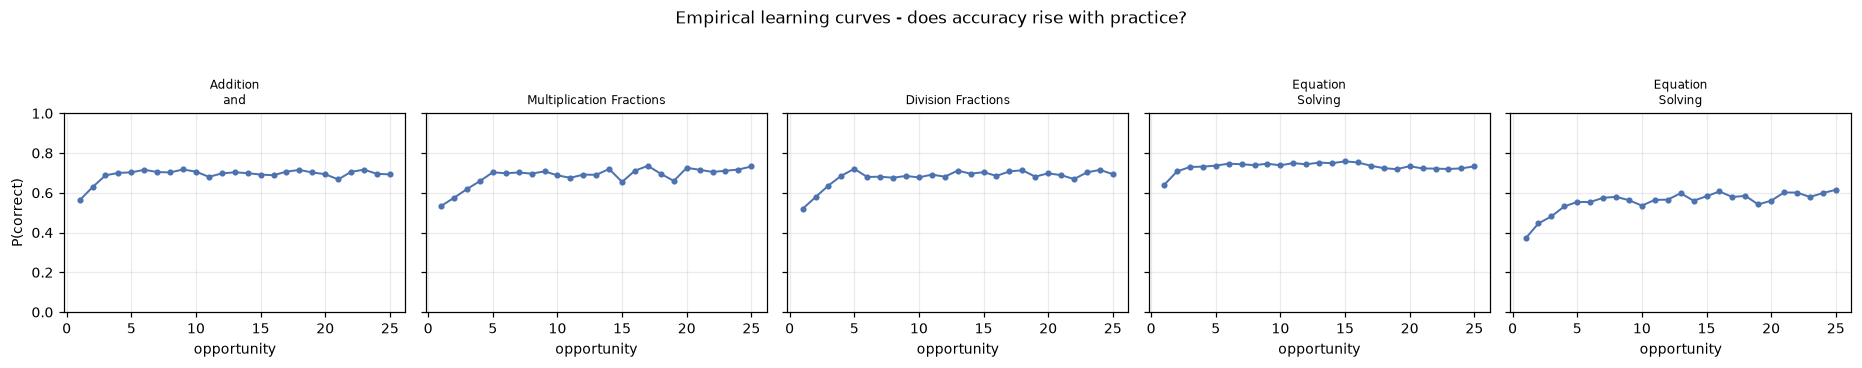

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(17, 3.1), sharey=True)
MAX_OPP, MIN_N = 25, 50

for ax, skill in zip(axes, SELECTED_SKILLS):
    sub = df[df["skill"] == skill]
    curve = sub.groupby("opportunity")["correct"].agg(["mean", "size"])
    curve = curve[(curve.index <= MAX_OPP) & (curve["size"] >= MIN_N)]

    ax.plot(curve.index, curve["mean"], "o-", ms=3, lw=1.3, color="#4C72B0")
    ax.set_ylim(0, 1)
    ax.set_xlabel("opportunity")
    ax.set_title("\n".join(skill.split(" ", 3)[:2]) if len(skill) > 30 else skill,
                 fontsize=8)
    ax.grid(alpha=0.25)

axes[0].set_ylabel("P(correct)")
fig.suptitle("Empirical learning curves - does accuracy rise with practice?", y=1.06)
fig.tight_layout()
fig.savefig(FIGURES / "empirical_learning_curves.png", bbox_inches="tight")
plt.show()

In [10]:
# Quantify it: accuracy at the first vs fifth opportunity, per skill.
rows = []
for skill in SELECTED_SKILLS:
    sub = df[df["skill"] == skill]
    first = sub.loc[sub["opportunity"] == 1, "correct"].mean()
    fifth = sub.loc[sub["opportunity"] == 5, "correct"].mean()
    rows.append((skill, first, fifth, fifth - first))

gain = pd.DataFrame(rows, columns=["skill", "opp_1", "opp_5", "gain"])
print(gain.round(3).to_string(index=False))
print(
    "\nA positive `gain` means students improve with practice - which is what BKT "
    "models.\nIf any skill is flat or negative, reconsider including it."
)

                               skill  opp_1  opp_5  gain
  Addition and Subtraction Fractions  0.562  0.703 0.140
            Multiplication Fractions  0.534  0.703 0.170
                  Division Fractions  0.519  0.721 0.201
 Equation Solving Two or Fewer Steps  0.639  0.737 0.098
Equation Solving More Than Two Steps  0.371  0.554 0.184

A positive `gain` means students improve with practice - which is what BKT models.
If any skill is flat or negative, reconsider including it.


## 2.7 Provenance table and save

In [11]:
provenance = prov.frame()
provenance["pct_of_start"] = (
    provenance["rows_remaining"] / provenance["rows_remaining"].iloc[0]
).round(4)

provenance.to_csv(PROCESSED / "provenance.csv", index=False)
per_skill.loc[SELECTED_SKILLS].to_csv(PROCESSED / "skill_summary.csv")

print("=== Provenance table ===")
print(provenance.to_string(index=False))

=== Provenance table ===
                   step  rows_remaining  rows_removed                                                      justification  pct_of_start
Raw subset, notebook 01         6123270             0                                                   12 of 35 columns        1.0000
  Binary `correct` only         6117947          5323                                    0/1 required for BKT likelihood        0.9991
           Skill-tagged         2629870       3488077                              BKT is fitted per knowledge component        0.4295
     Main problems only         2543677         86193                          Scaffolding duplicates the parent attempt        0.4154
    Valid response time         2543677             0                          Zero/negative values are recording errors        0.4154
      Timestamp present         2496985         46692                                   Required to derive `opportunity`        0.4078
           Deduplicated       

In [12]:
OUT = PROCESSED / "interactions_clean.parquet"
df.to_parquet(OUT, index=False)

print(f"saved: {OUT}  ({OUT.stat().st_size / 1e6:.0f} MB)")
print(f"\nFinal dataset")
print(f"  rows                  : {len(df):,}")
print(f"  students              : {df['user_id'].nunique():,}")
print(f"  skills                : {df['skill'].nunique()}")
print(f"  (student, skill) pairs: {len(df.groupby(['user_id','skill'], observed=True)):,}")
print(f"  mean sequence length  : {len(df) / len(df.groupby(['user_id','skill'], observed=True)):.1f}")
print(f"  overall accuracy      : {df['correct'].mean():.3f}")
print(f"  hint rate             : {(df['hint_count'] > 0).mean():.3f}")

saved: C:\Users\vedac\Desktop\EATS\data\processed\interactions_clean.parquet  (8 MB)

Final dataset
  rows                  : 474,011
  students              : 12,119
  skills                : 5
  (student, skill) pairs: 23,755
  mean sequence length  : 20.0
  overall accuracy      : 0.681
  hint rate             : 0.171
